In [199]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [200]:
def f(x):
    return 5*x**2-9*x+20

In [201]:
f(2.0)

22.0

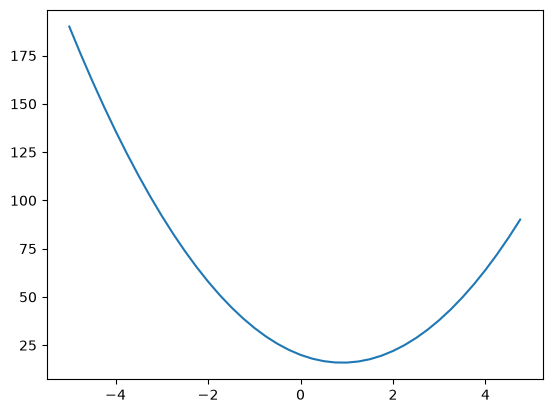

In [202]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

How to get f(x)'s derivative?
1. By formula, yet explict function is needed. 
2. By definition, we change a little on x, to see how much the f(x) changes. 

In [203]:
h = 0.00001 # a small positive step
x = -3.0
(f(x+h)-f(x))/h

-38.99995000153922

In [204]:
# more complex: multiple input values
a = 2.0
b = -3.0
c = 10.0
d = a*b + c # d=f(a,b,c)=a*b+c
d

4.0

In [205]:
h = 0.000001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c

(d2-d1)/h # partial derivative of d respect to a

0.9999999992515995

In [226]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        # printable representation (differ from 'readable' format)
        return f'Value(data={self.data})'

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * (-1)
    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other, label=f'{other}')
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other,(self, ), f'**{other}' )
        def _backward():
            if other != 0:
                self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * (other ** -1)

    def tanh(self):
        out = Value(float(np.tanh(self.data)), (self,), 'tanh')
        def _backward():
            self.grad += (1 - out.data**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build_topo(v): # postorder traversal
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        self.grad = 1.0
        build_topo(self)
        topo.reverse()
        for n in topo:
            n._backward()

a = Value(2.0, label='a')
b = Value(4.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-1.0, label='f')
L = d * f; L.label='L'
L

Value(data=-18.0)

$$
\frac{\partial}{\partial x}(xy)=y
$$
$$
\frac{\partial}{\partial x}(x+y)=1
$$
$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y} \frac{\partial y}{\partial x}
$$

In [207]:
L.grad = 1.0
f.grad = d.data
d.grad = f.data
e.grad = d.grad * 1
c.grad = d.grad * 1
b.grad = e.grad * a.data
a.grad = e.grad * b.data

In [208]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot


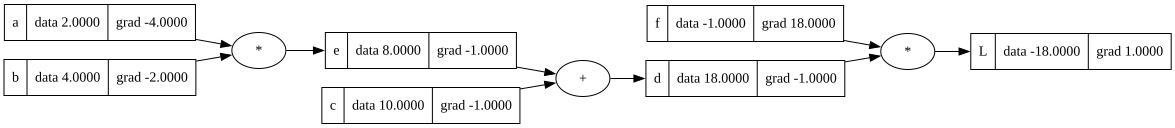

In [209]:
draw_dot(L)

In [210]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-14.588456000000003


In [211]:
def lol():
    h = 0.00001

    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data


    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h
    print((L2-L1)/h)
lol()

0.9999999999621422


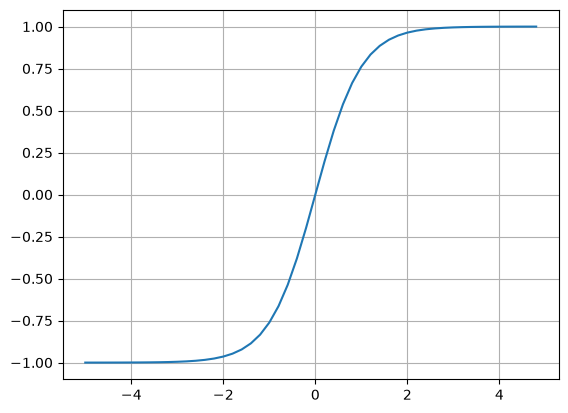

In [212]:
# activation function
xs = np.arange(-5,5, 0.2)
ys = np.tanh(xs)
plt.plot(xs, ys)
plt.grid()

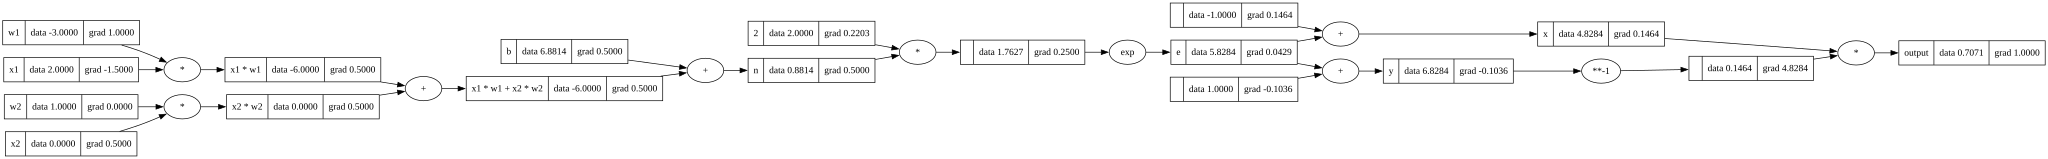

In [227]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b') # make output=1/sqrt(2)
x1w1 = x1*w1; x1w1.label='x1 * w1'
x2w2 = x2*w2; x2w2.label='x2 * w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1 * w1 + x2 * w2'
n = x1w1x2w2 + b; n.label='n'
# o = n.tanh(); o.label = 'output'
# break up tanh
e = (2*n).exp(); e.label = 'e'
x = e - 1; x.label = 'x'
y = e + 1; y.label = 'y'
o = x / y; o.label = 'output'
o.backward()
draw_dot(o)

$$
\frac{\text{d}}{\text{d}x}\tanh x=1-\tanh^2 x 
$$

Topological Sort
<img src='topo.webp' />

In [214]:
# topological sort
topo = []
visited = set()
def build_topo(v): # postorder traversal
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

o.grad = 1.0
build_topo(o)
topo.reverse()
for n in topo:
    n._backward()

In [215]:
# backward manually
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()




In [216]:
# backward explicitly
o.grad = 1
n.grad = (1 - o.data**2) * o.grad

b.grad = n.grad * 1  # infact, just n.grad
x1w1x2w2.grad = n.grad * 1  # infact, just n.grad
x1w1.grad = x1w1x2w2.grad * 1  # infact, just n.grad
x2w2.grad = x1w1x2w2.grad * 1  # infact, just n.grad

w1.grad = x1w1.grad * x1.data
w2.grad = x2w2.grad * x2.data
x1.grad = x1w1.grad * w1.data
x2.grad = x2w2.grad * w2.data


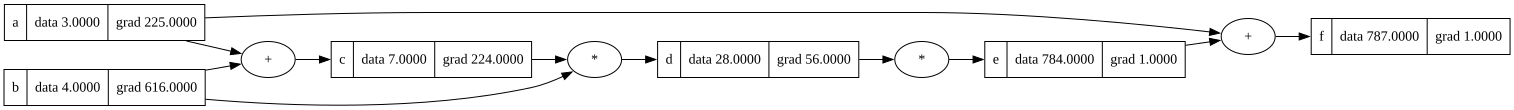

In [217]:
a = Value(3.0, label='a')
b = Value(4.0, label='b')
c = a + b; c.label = 'c'
d = b * c; d.label = 'd'
e = d * d; e.label = 'e'
f = a + e; f.label = 'f'

f.backward()
draw_dot(f)